In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import csv
import seaborn as sns
from scipy.stats import ttest_ind

In [7]:
path='/Users/barber.527/Documents/Rojas_Lab/data/HPLC/'
expt_id='PG_analysis_paper'

In [8]:
data_labels = []
with open(path+expt_id+'.csv') as csv_file:
    csv_reader = csv.reader(csv_file, delimiter=',')
    line_count = 0
    for row in csv_reader:
        data_labels.append(row) # Data should be saved in UTF-8 format
        line_count += 1
# print(data_labels)

In [9]:
cols=['Condition']+[data[0] for data in data_labels[1:]]
df=pd.DataFrame(columns=cols)
for ind in range(len(data_labels[0][1:])):
    temp_data=[data_labels[0][1+ind]]+[float(temp_data1[ind+1]) for temp_data1 in data_labels[1:]]
    temp_df=pd.DataFrame(columns=cols,data=[temp_data])
    df=pd.concat([df,temp_df])

In [10]:
temp1=df.groupby('Condition')['Sum trimers'].describe()
temp1['se']=temp1['std']/np.sqrt(2)
temp1

,count,mean,std,min,25%,50%,75%,max,se
Condition,,,,,,,,,
WT,2.0,8.0045,0.939745,7.34,7.67225,8.0045,8.33675,8.669,0.6645
ΔtagO,2.0,9.9060,0.192333,9.77,9.83800,9.9060,9.97400,10.042,0.1360


In [11]:
temp1=df.groupby('Condition')['Sum tetramers'].describe()
temp1['se']=temp1['std']/np.sqrt(2)
temp1

,count,mean,std,min,25%,50%,75%,max,se
Condition,,,,,,,,,
WT,2.0,0.8365,0.184555,0.706,0.77125,0.8365,0.90175,0.967,0.1305
ΔtagO,2.0,1.6100,0.272943,1.417,1.51350,1.6100,1.70650,1.803,0.1930


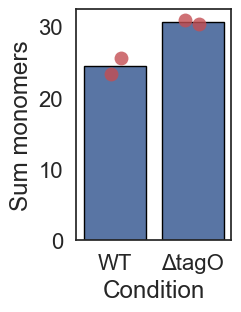

<Figure size 640x480 with 0 Axes>

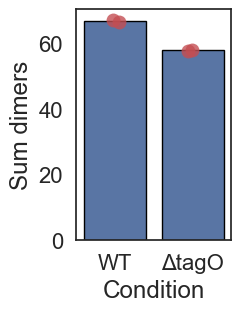

<Figure size 640x480 with 0 Axes>

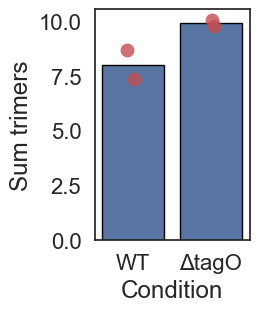

<Figure size 640x480 with 0 Axes>

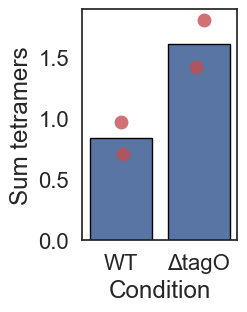

<Figure size 640x480 with 0 Axes>

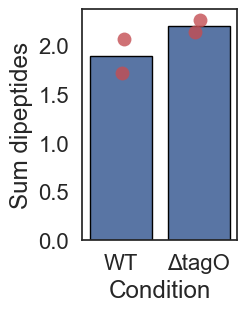

<Figure size 640x480 with 0 Axes>

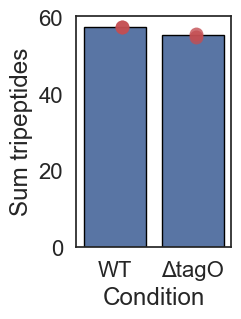

<Figure size 640x480 with 0 Axes>

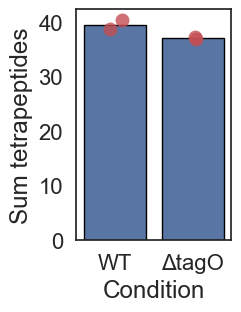

<Figure size 640x480 with 0 Axes>

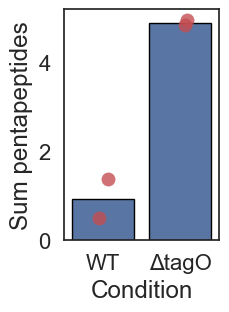

<Figure size 640x480 with 0 Axes>

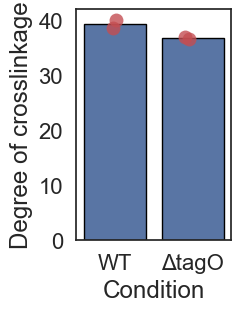

<Figure size 640x480 with 0 Axes>

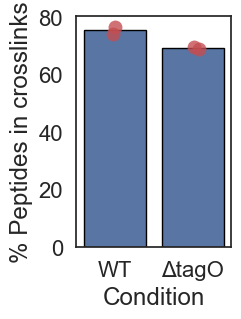

<Figure size 640x480 with 0 Axes>

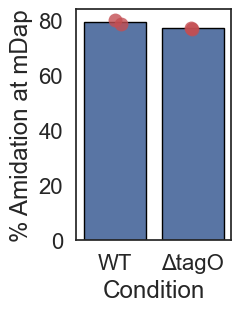

<Figure size 640x480 with 0 Axes>

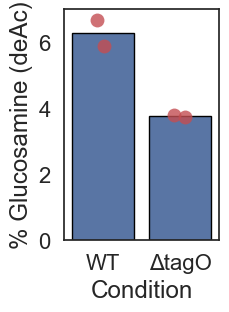

<Figure size 640x480 with 0 Axes>

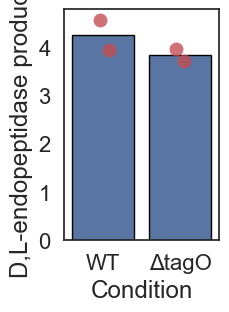

<Figure size 640x480 with 0 Axes>

In [13]:
sns.set(font_scale=1.45)
col=sns.color_palette()[0]
sns.set_style('white')

out_path='./outputs/HPLC/'
for val in cols[1:]:
    fig=plt.figure(figsize=[2,3])
    ax=sns.barplot(data=df,x='Condition',y=val,estimator=np.mean,color=col,capsize=0.4,edgecolor="black",
    errorbar=None)
    sns.stripplot(data=df,x='Condition',y=val,color='r',alpha=0.8, ax=ax,dodge=False,size=10.0,edgecolor='k')
    fig.savefig(out_path+val[:11]+'.pdf',bbox_inches='tight')
    plt.show()
    plt.clf()

In [14]:
df.keys()

Index(['Condition', 'Sum monomers', 'Sum dimers', 'Sum trimers',
       'Sum tetramers', 'Sum dipeptides', 'Sum tripeptides',
       'Sum tetrapeptides', 'Sum pentapeptides', 'Degree of crosslinkage',
       '% Peptides in crosslinks', '% Amidation at mDap',
       '% Glucosamine (deAc)', 'D,L-endopeptidase products'],
      dtype='object')

In [15]:
var='% Peptides in crosslinks'
ttest_ind(df[df.Condition=='ΔtagO'][var], df[df.Condition=='WT'][var])

Ttest_indResult(statistic=-5.278051681328062, pvalue=0.03407252101668558)

In [16]:
var='% Glucosamine (deAc)'
ttest_ind(df[df.Condition=='ΔtagO'][var], df[df.Condition=='WT'][var])

Ttest_indResult(statistic=-6.33141087946348, pvalue=0.024049631818585143)

In [17]:
var='Sum trimers'
ttest_ind(df[df.Condition=='ΔtagO'][var], df[df.Condition=='WT'][var])

Ttest_indResult(statistic=2.8034373957060024, pvalue=0.1071702041606666)

In [18]:
var='Sum tetramers'
ttest_ind(df[df.Condition=='ΔtagO'][var], df[df.Condition=='WT'][var])

Ttest_indResult(statistic=3.320040632998284, pvalue=0.07998822787782547)

In [19]:
var='Sum dimers'
ttest_ind(df[df.Condition=='ΔtagO'][var], df[df.Condition=='WT'][var])

Ttest_indResult(statistic=-24.77442685484082, pvalue=0.0016252979066836912)

In [20]:
var='Sum monomers'
ttest_ind(df[df.Condition=='ΔtagO'][var], df[df.Condition=='WT'][var])

Ttest_indResult(statistic=5.2780516813280745, pvalue=0.03407252101668543)

In [21]:
var='D,L-endopeptidase products'
ttest_ind(df[df.Condition=='ΔtagO'][var], df[df.Condition=='WT'][var])

Ttest_indResult(statistic=-1.2478090795303827, pvalue=0.3383862382906331)